<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_4_Part_of_Speech_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: POS Tagging


# Task 1: Import Libraries and Download Resources

In [6]:
# Installing NLTK
!pip install nltk

import nltk
import pandas as pd
import matplotlib.pyplot as plt

# Downloading required resources
resources = [
    'punkt',
    'punkt_tab',
    'stopwords',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng'
]

for r in resources:
    nltk.download(r)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


# Task 2: Load and Preprocess Text Data

In [7]:
# Uploading the file
from google.colab import files
uploaded = files.upload()

# Getting the file name
file_name = list(uploaded.keys())[0]

# Reading text file
with open(file_name, 'r', encoding='utf-8') as file:
    text = file.read()

# Tokenization (split into words)
tokens = word_tokenize(text)

# Removing the punctuation and stopwords
import string
stop_words = set(stopwords.words('english'))

cleaned_tokens = [
    word.lower()
    for word in tokens
    if word.isalpha() and word.lower() not in stop_words
]

print("Sample cleaned tokens:", cleaned_tokens[:20])

Saving PeterRabbit.txt to PeterRabbit (1).txt
Sample cleaned tokens: ['upon', 'time', 'four', 'little', 'rabbits', 'names', 'flopsy', 'mopsy', 'peter', 'lived', 'mother', 'underneath', 'root', 'big', 'dears', 'said', 'old', 'mrs', 'rabbit', 'one']


# Task 3: Perform POS Tagging

In [8]:
# Applying POS tagging
pos_tags = pos_tag(cleaned_tokens)

# Converting to DataFrame for easy analysis
df = pd.DataFrame(pos_tags, columns=['Word', 'POS'])

# Displaying first few rows
df.head()

,Word,POS
0,upon,IN
1,time,NN
2,four,CD
3,little,JJ
4,rabbits,NNS


# Task 4: Analyze and Visualize POS Tag Distribution

In [9]:
# Counting the frequency of each POS tag
pos_counts = df['POS'].value_counts()

print(pos_counts)

POS
NN     148
JJ      70
VBD     54
RB      46
NNS     37
VBG     21
VBP     15
VB      14
IN      14
VBN     10
CD       7
MD       5
PRP      2
VBZ      2
RBR      2
JJS      2
RP       2
NNP      1
JJR      1
Name: count, dtype: int64


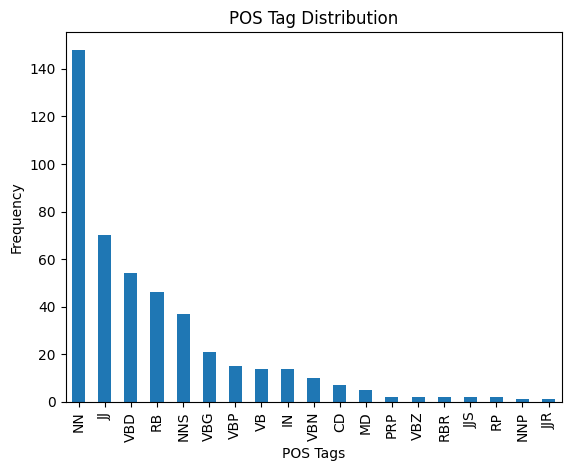

In [12]:
# Plotting POS distribution
plt.figure()
pos_counts.plot(kind='bar')
plt.title("POS Tag Distribution")
plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.show()

# Task 5: Save Results

In [13]:
# Saving tagged data to CSV
df.to_csv("pos_tagged_output.csv", index=False)

# Saving POS frequency to text file
with open("pos_distribution.txt", "w") as f:
    for tag, count in pos_counts.items():
        f.write(f"{tag}: {count}\n")

print("All files saved successfully!")

All files saved successfully!
